In [6]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
from tqdm.notebook import tqdm
import awkward as ak
from bosonic_dm.efficiency import build_labels_dicts
from bosonic_dm.plotting.efficiency import plot_efficiency_comparison
from bosonic_dm.plotting.utils import _DET_TYPE_MAP, _DET_TYPE_COLOR

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [17]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)
chmap_ak = ak.Array(chmap.group("system").geds.values())
ges_sorted = chmap_ak.name

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")
DET_TYPE_MAP = {"B": "BEGe", "C": "COAX", "V": "ICPC", "P": "PPC"}
DET_TYPE_COLOR = {
    "BEGe": "tab:blue",
    "COAX": "tab:orange",
    "ICPC": "tab:green",
    "PPC": "tab:red",
}

simulated_energies = list(range(200, 1100, 100))

dictionaries_dir_old = "../data/v1/dictionaries" ## TODO: change with "inputs"

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd0f62d6f70>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd0f62d6a20>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd0f62d5ee0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd0f62d6020>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd0f6265e40>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd0f6265a80>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

# Read dictionaries

In [18]:
dictionaries_dir = "../data/v2/dictionaries"
rawid_by_det_type = Props.read_from(f'{dictionaries_dir_old}/rawid_by_det_type.yaml')
eres_dict = Props.read_from(f"{dictionaries_dir_old}/eres_dict.yaml")
groups_dict = Props.read_from(f"{dictionaries_dir_old}/detector-grouping/groups_dict.yaml")
interactions = ['axio-electric', 'dark-compton']

# Detector type division

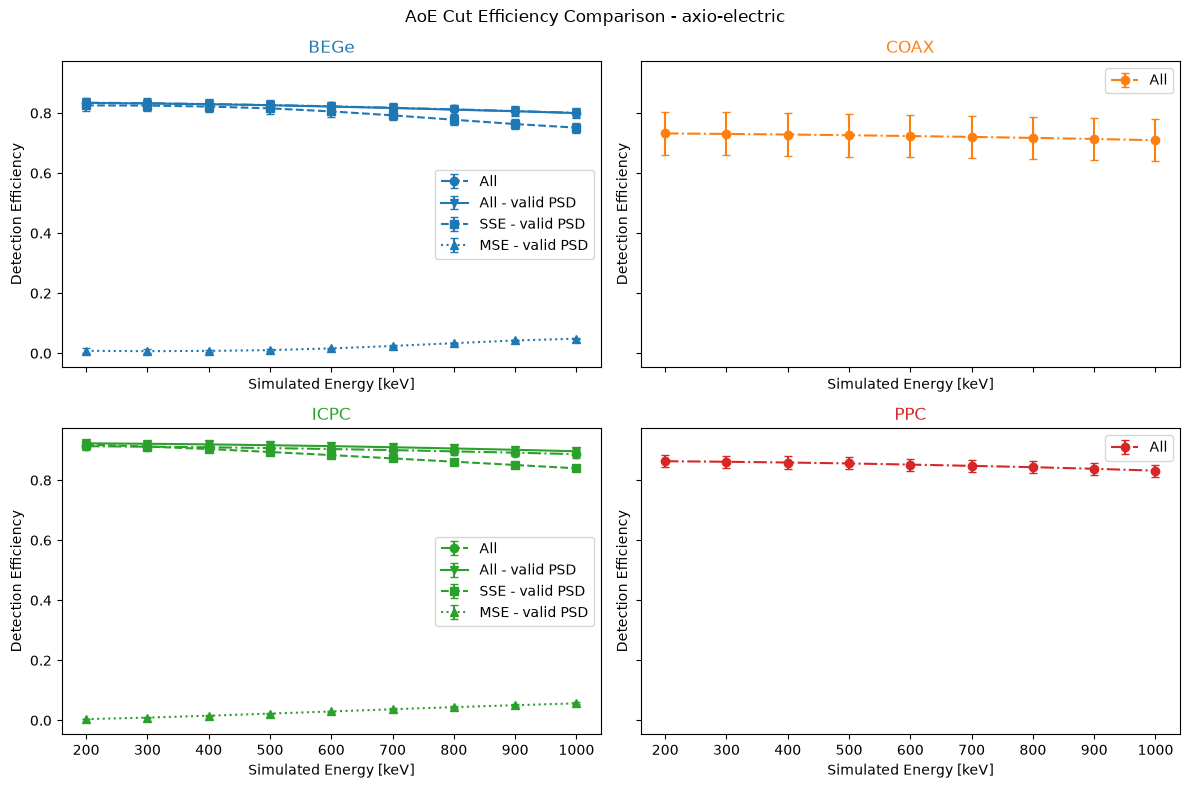

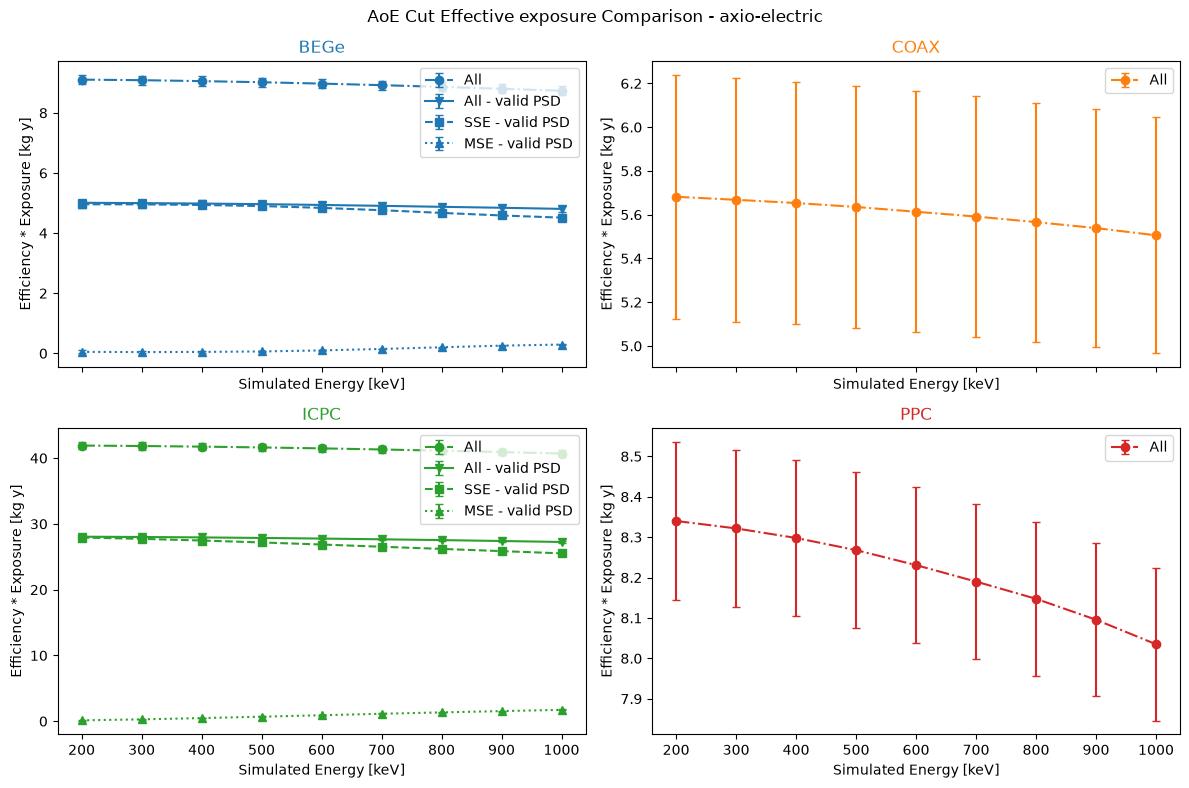

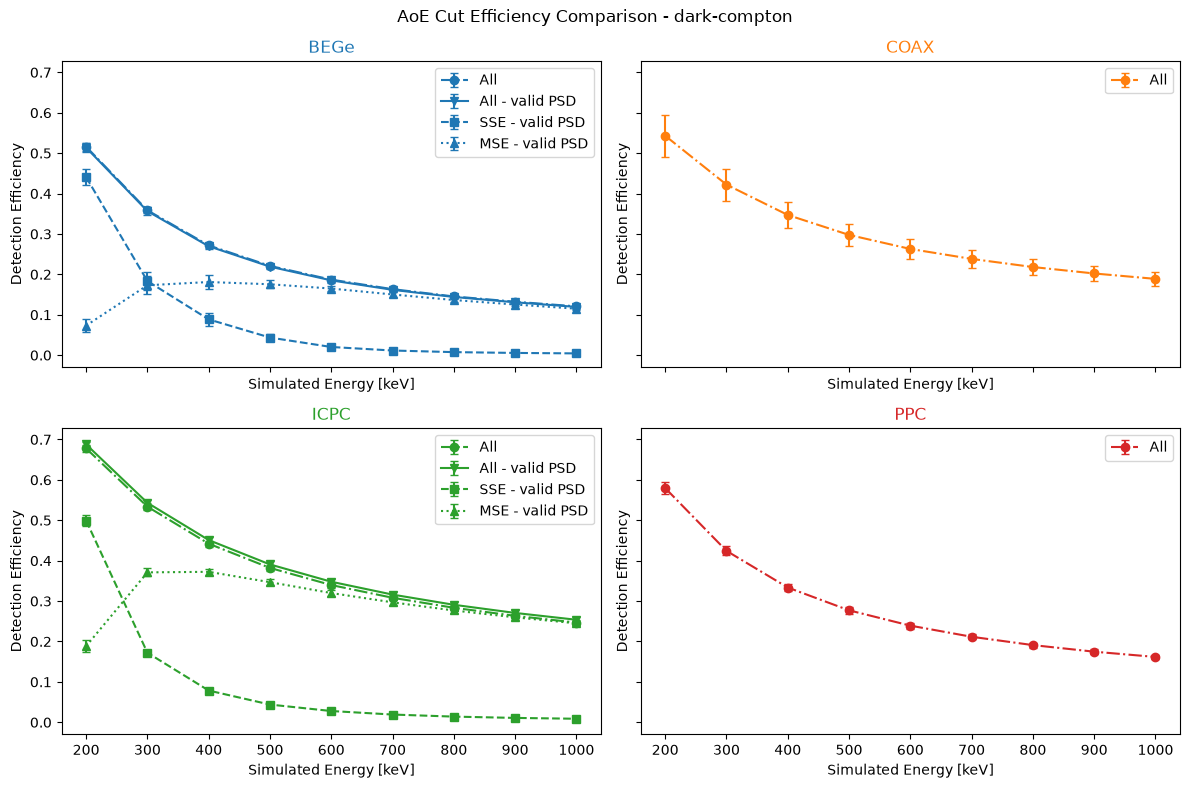

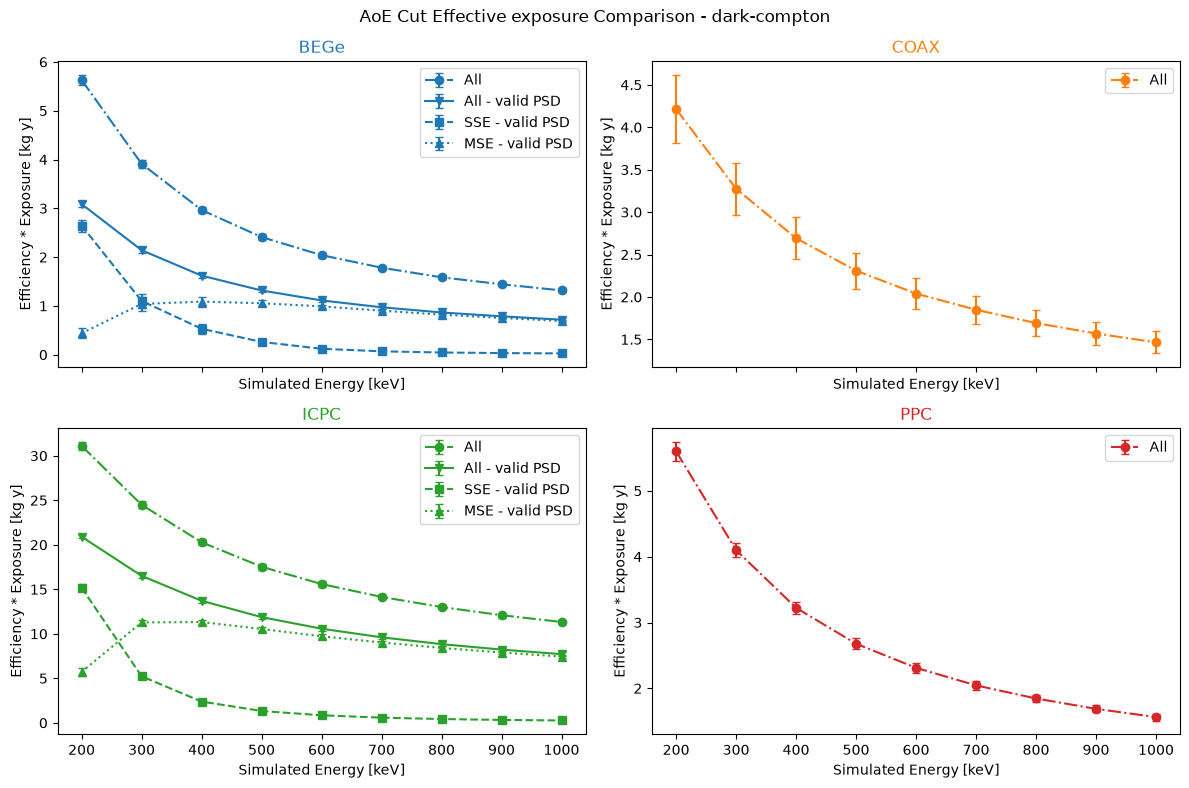

In [10]:
group_by = "detector_type"

plots_config = {
    'efficiency': ('AoE Cut Efficiency Comparison', '_detection-efficiency.png', "Detection Efficiency", True),
    'eff_exp': ('AoE Cut Effective exposure Comparison', '_effective-exposure.png', 'Efficiency * Exposure [kg y]', False)
}

det_types_efficiency = {}

for interaction in interactions:
    
    input_dict = Props.read_from(f"{dictionaries_dir}/{interaction}_efficiency.yaml")
    
    labels_dicts = build_labels_dicts(
        input_dict,
        group_by=group_by,
        detector_groups=groups_dict,
        eres_dict=eres_dict,
    )
    
    det_types_efficiency[interaction] = labels_dicts

    for plot_type, (plot_title, file_name, ylabel, sharey) in plots_config.items():

        save_path = f"../data/v2/plots/{interaction}{file_name}"
        
        fig, axes = plot_efficiency_comparison(
            labels_dicts=labels_dicts,
            interaction=interaction,
            plot_type=plot_type,
            plot_title=plot_title,
            ylabel=ylabel,
            sharey=sharey,
            save_path=save_path,
            group_by=group_by,
        )    
        plt.show()

In [20]:
groups_dict['COAX'].pop('C000RG1')

'all'

In [21]:
groups_dict['COAX']

{'C000RG2': 'all',
 'C00ANG3': 'all',
 'C00ANG5': 'all',
 'C00ANG2': 'all',
 'C00ANG4': 'all'}

In [22]:
groups_dict['COAX_RG1'] = {
    'C000RG1' : 'all'
}


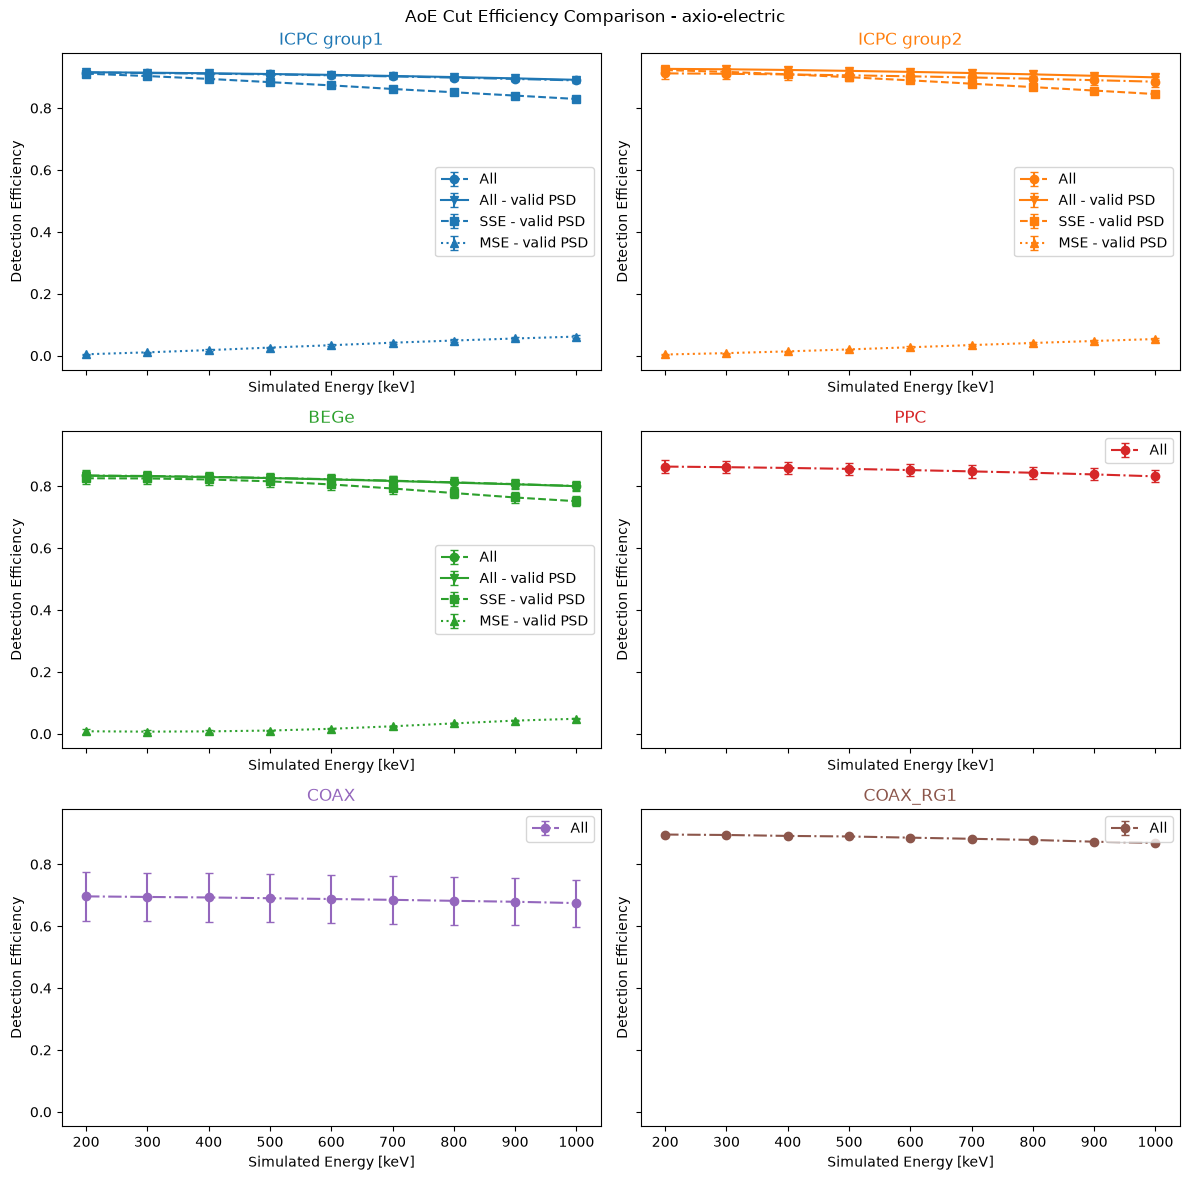

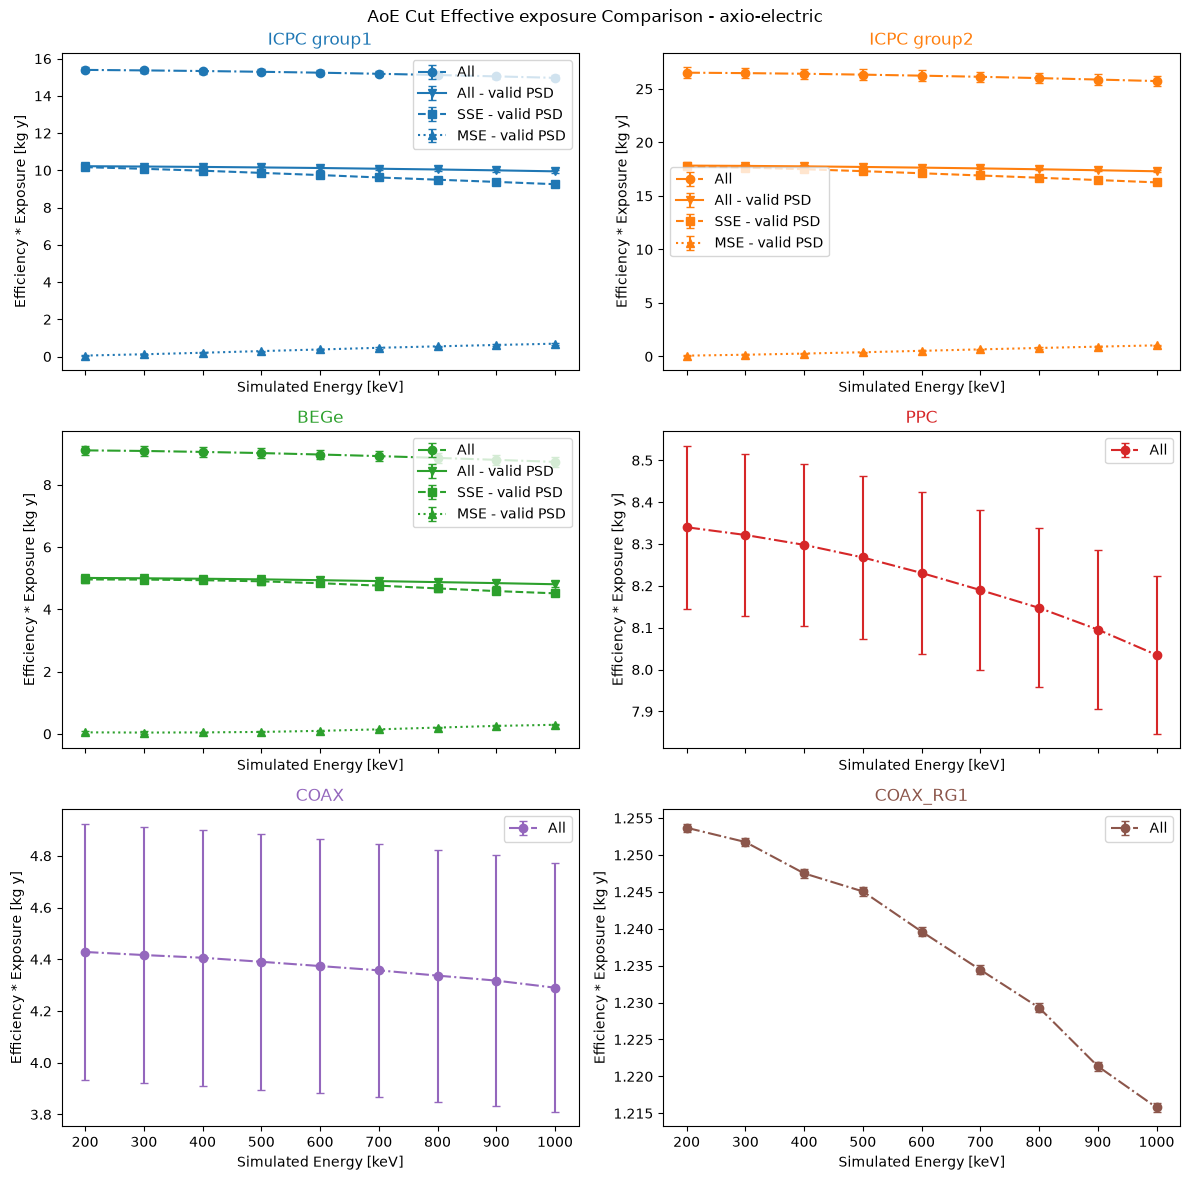

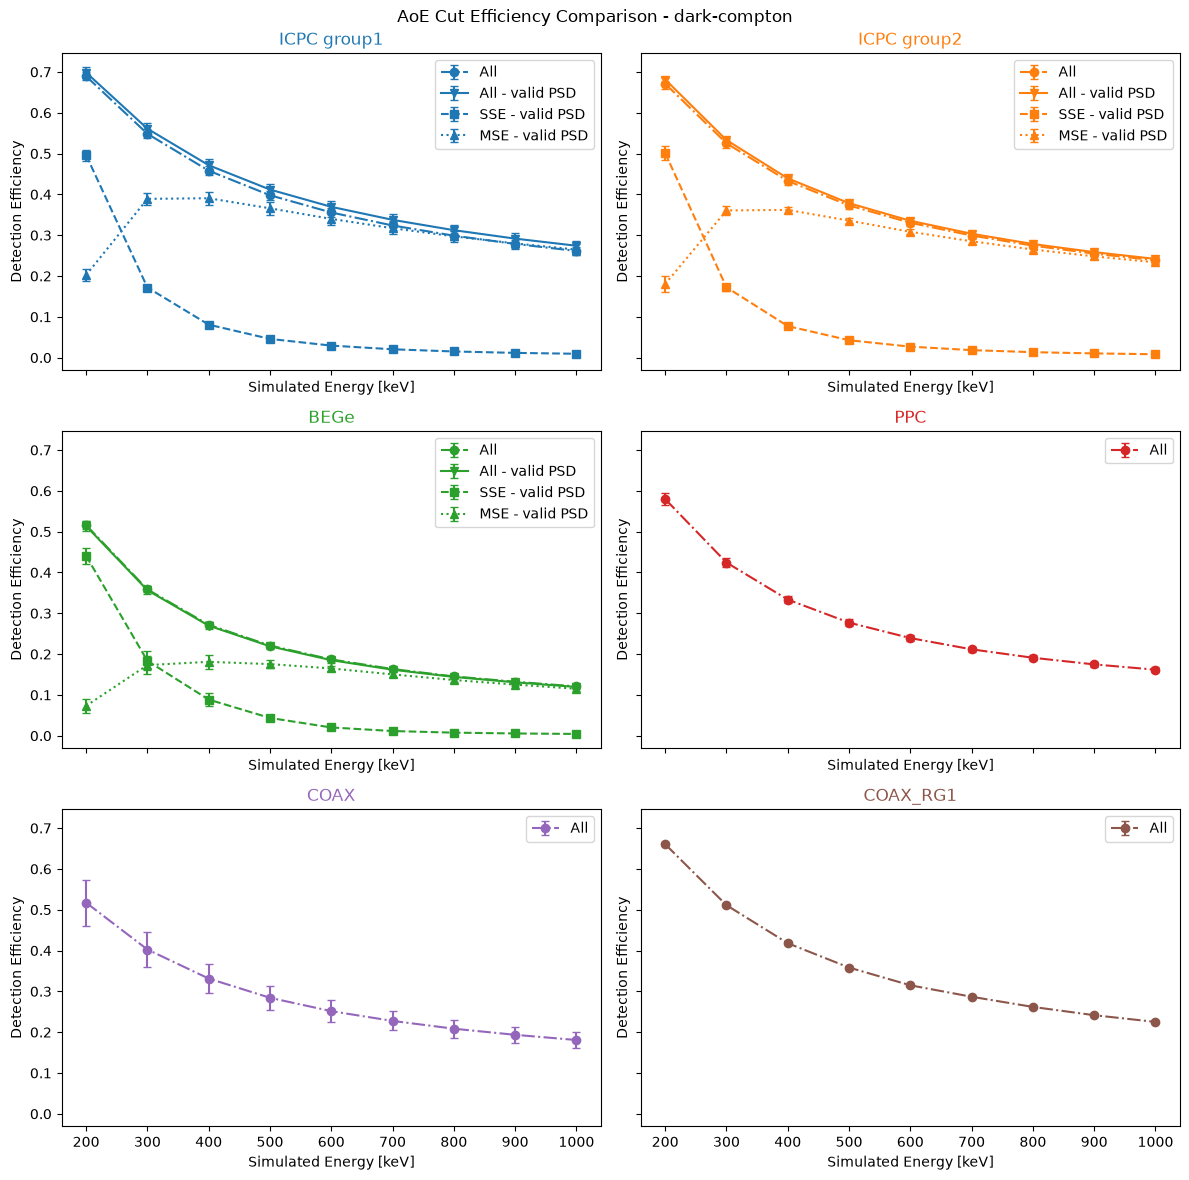

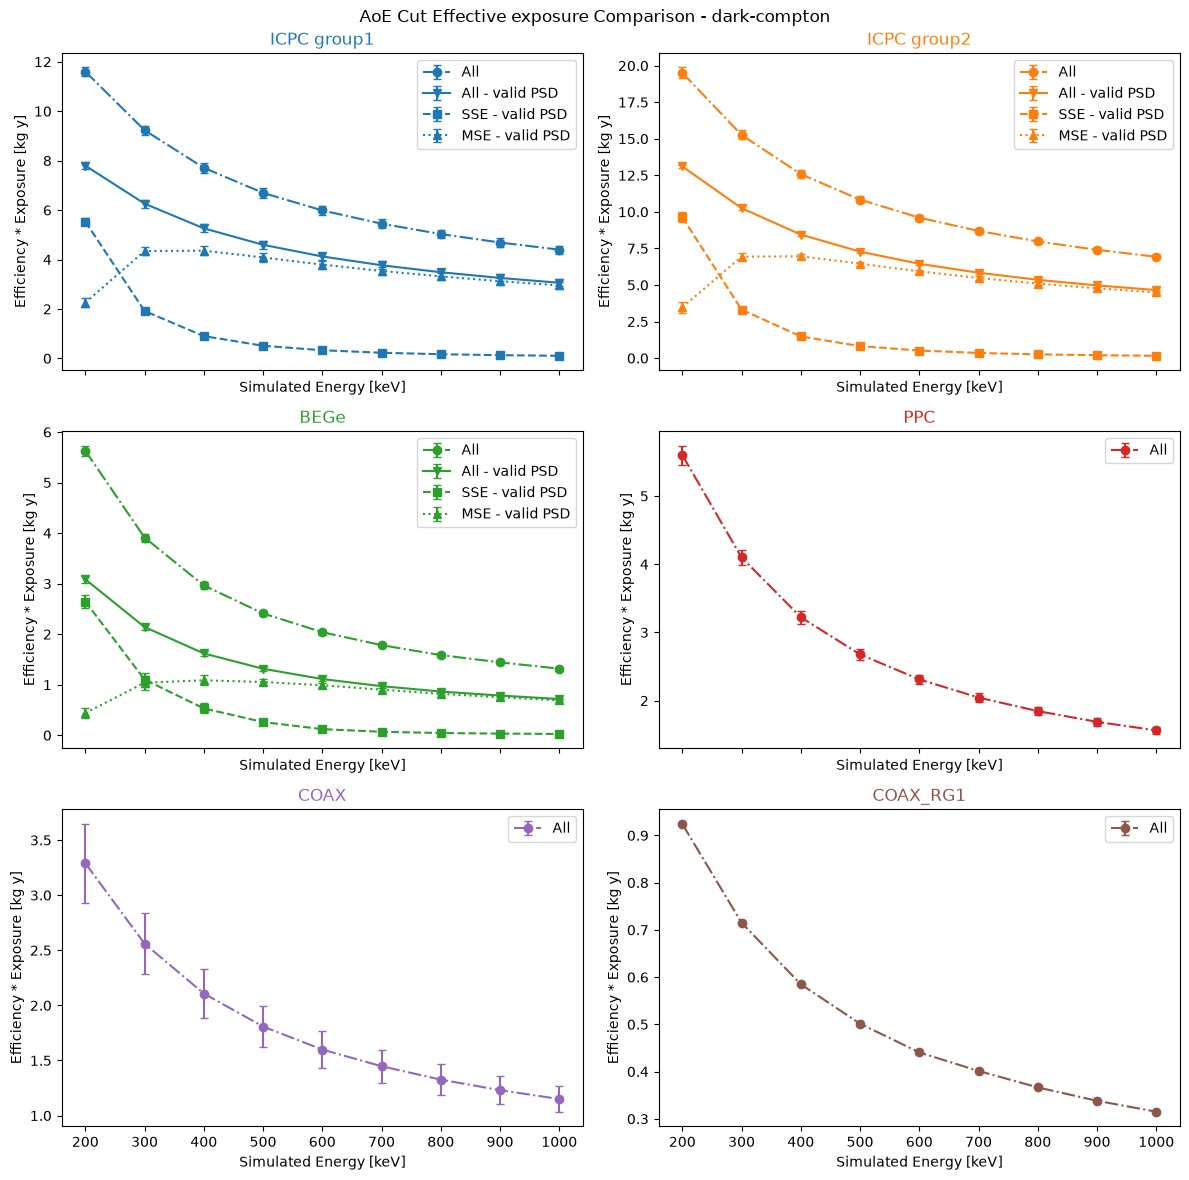

In [23]:
group_by = "detector_group"

plots_config = {
    'efficiency': ('AoE Cut Efficiency Comparison', '_detection-efficiency_groups.png', "Detection Efficiency", True),
    'eff_exp': ('AoE Cut Effective exposure Comparison', '_effective-exposure_groups.png', 'Efficiency * Exposure [kg y]', False)
}

det_groups_efficiency = {}

for interaction in interactions:
    
    input_dict = Props.read_from(f"{dictionaries_dir}/{interaction}_efficiency.yaml")
    
    labels_dicts = build_labels_dicts(
        input_dict,
        group_by=group_by,
        detector_groups=groups_dict,
        eres_dict=eres_dict,
    )
    
    det_groups_efficiency[interaction] = labels_dicts

    for plot_type, (plot_title, file_name, ylabel, sharey) in plots_config.items():

        save_path = f"../data/v2/plots/{interaction}{file_name}"
        
        fig, axes = plot_efficiency_comparison(
            labels_dicts=labels_dicts,
            interaction=interaction,
            plot_type=plot_type,
            plot_title=plot_title,
            ylabel=ylabel,
            sharey=sharey,
            save_path=save_path,
            group_by=group_by,
        )    
        plt.show()